[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ManuelSanchezUribe/MIA_IMT3850_public/blob/main/Semana3/PageRank_example.ipynb)

La **Wikipedia Vote Network** es un conjunto de datos empírico extraído y mantenido por el Stanford Network Analysis Project (SNAP). Contiene el historial de las votaciones para las elecciones de administradores en Wikipedia, un proceso conocido como Request for Adminship (RfA), desde la creación de la plataforma hasta enero de 2008.

Características y Estructura de la Red:

- Nodos (Usuarios): La base de datos está compuesta por 7.115 nodos. Cada nodo representa a un usuario de Wikipedia que participó en el proceso electoral, ya sea como candidato o como votante.

- Aristas (Votos): Existen 103.689 aristas direccionales en el grafo. Una arista que va desde un nodo hacia otro indica explícitamente que el primer usuario emitió un voto sobre el segundo.

- Volumen de Elecciones: El registro documenta un total de 2.794 elecciones. De este total, 1.235 resultaron en la promoción exitosa del candidato, mientras que 1.559 fueron rechazadas.

- Distribución de Influencia: Aproximadamente la mitad de los votos registrados en el sistema provienen de administradores ya establecidos. La otra mitad corresponde a votos emitidos por usuarios ordinarios de la comunidad.

El proceso electoral modelado en esta base de datos corresponde al sistema oficial de Wikipedia llamado **Solicitud de permisos de administrador** (RfA, por sus siglas en inglés). Es un mecanismo de evaluación comunitaria basado en la confianza y el consenso, no en una simple elección de mayoría matemática.

* **La Candidatura (El Nodo Destino):** Cualquier usuario registrado puede postularse o ser nominado por un tercero para adquirir herramientas de administrador (capacidad de borrar páginas, bloquear cuentas vandálicas, proteger artículos, etc.). Al iniciarse el proceso, se abre una página de discusión pública dedicada exclusivamente a evaluar a ese candidato.
* **La Votación (La Arista o Enlace):** Durante un período típicamente de siete días, la comunidad debate la idoneidad del candidato. Los usuarios revisan su historial de ediciones, su comportamiento en disputas previas y emiten un voto (que puede ser a favor, en contra o neutral), acompañándolo de una justificación escrita. En el dataset de Stanford, una arista dirigida de $A \to B$ indica que el usuario $A$ participó en la página de nominación del usuario $B$ emitiendo un voto explícito.
* **La Resolución:** Al finalizar el plazo de siete días, no gana simplemente quien tenga más votos. Un "Burócrata" (un administrador con privilegios superiores) evalúa si existe un consenso real. Históricamente, se exige una tasa de aprobación mínima del 70% al 75% para otorgar los permisos.

La pertinencia de usar PageRank para analizar este proceso radica en la **asimetría de la influencia**. En la práctica social de Wikipedia, no todos los votos pesan lo mismo. El apoyo (o rechazo) de un administrador veterano, altamente respetado por sus pares, moldea la opinión del resto de los votantes y del burócrata de forma mucho más contundente que el voto de una cuenta recién creada.

PageRank es excepcionalmente útil aquí porque cuantifica matemáticamente esa reputación social sin necesidad de leer el texto de los debates ni saber quién tiene un cargo oficial. El algoritmo identifica que un candidato es importante si recibe votos de personas que, a su vez, poseen una alta autoridad topológica conferida por el resto de la red.

¿Te resultaría útil que añadamos un bloque de código al cuaderno que calcule qué porcentaje de los votos del "Top 50" (la élite de PageRank) fue dirigido a otros miembros de esa misma élite, para ilustrarles a los estudiantes cómo los nodos dominantes tienden a retroalimentar su centralidad?

In [3]:
import urllib.request
%pip install networkx
import networkx as nx
import pandas as pd

# 1. Descargar el dataset desde Stanford SNAP
url = "https://snap.stanford.edu/data/wiki-Vote.txt.gz"
file_name = "wiki-Vote.txt.gz"
print("Descargando la base de datos real (Wikipedia Vote Network)...")
urllib.request.urlretrieve(url, file_name)

# 2. Construir el grafo dirigido
# Ignoramos las líneas de metadatos/comentarios que empiezan con '#'
print("Construyendo el grafo dirigido en memoria...")
G = nx.read_edgelist(file_name, create_using=nx.DiGraph(), comments='#')

print(f"Topología de la red -> Nodos (Usuarios): {G.number_of_nodes()}")
print(f"Topología de la red -> Aristas (Votos): {G.number_of_edges()}")

     |████████████████████████████████| 2.1 MB 9.2 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.
Descargando la base de datos real (Wikipedia Vote Network)...
Construyendo el grafo dirigido en memoria...
Topología de la red -> Nodos (Usuarios): 7115
Topología de la red -> Aristas (Votos): 103689


In [4]:
print("\nCalculando la centralidad de los usuarios...")

# Ejecutar PageRank (factor de amortiguamiento clásico de 0.85)
pagerank_scores = nx.pagerank(G, alpha=0.85)

# Contar cuántos votos directos recibió cada usuario (Grado de entrada)
in_degree = dict(G.in_degree())


Calculando la centralidad de los usuarios...


In [5]:
# 3. Crear un DataFrame con las métricas competitivas
resultados = pd.DataFrame({
    'ID Usuario': list(G.nodes()),
    'Votos Recibidos (In-Degree)': [in_degree[n] for n in G.nodes()],
    'Score PageRank': [pagerank_scores[n] for n in G.nodes()]
})

# Ordenar a los usuarios por su Score de PageRank descendente
top_usuarios = resultados.sort_values(by='Score PageRank', ascending=False).head(10).reset_index(drop=True)

print("\n--- Top 10 Usuarios más influyentes según PageRank ---")
print(top_usuarios)


--- Top 10 Usuarios más influyentes según PageRank ---
  ID Usuario  Votos Recibidos (In-Degree)  Score PageRank
0       4037                          457        0.004613
1         15                          361        0.003681
2       6634                          203        0.003525
3       2625                          331        0.003286
4       2398                          340        0.002605
5       2470                          149        0.002530
6       2237                          181        0.002505
7       4191                          259        0.002266
8       7553                          190        0.002170
9       5254                          265        0.002150


Generando visualización del subgrafo de élite...


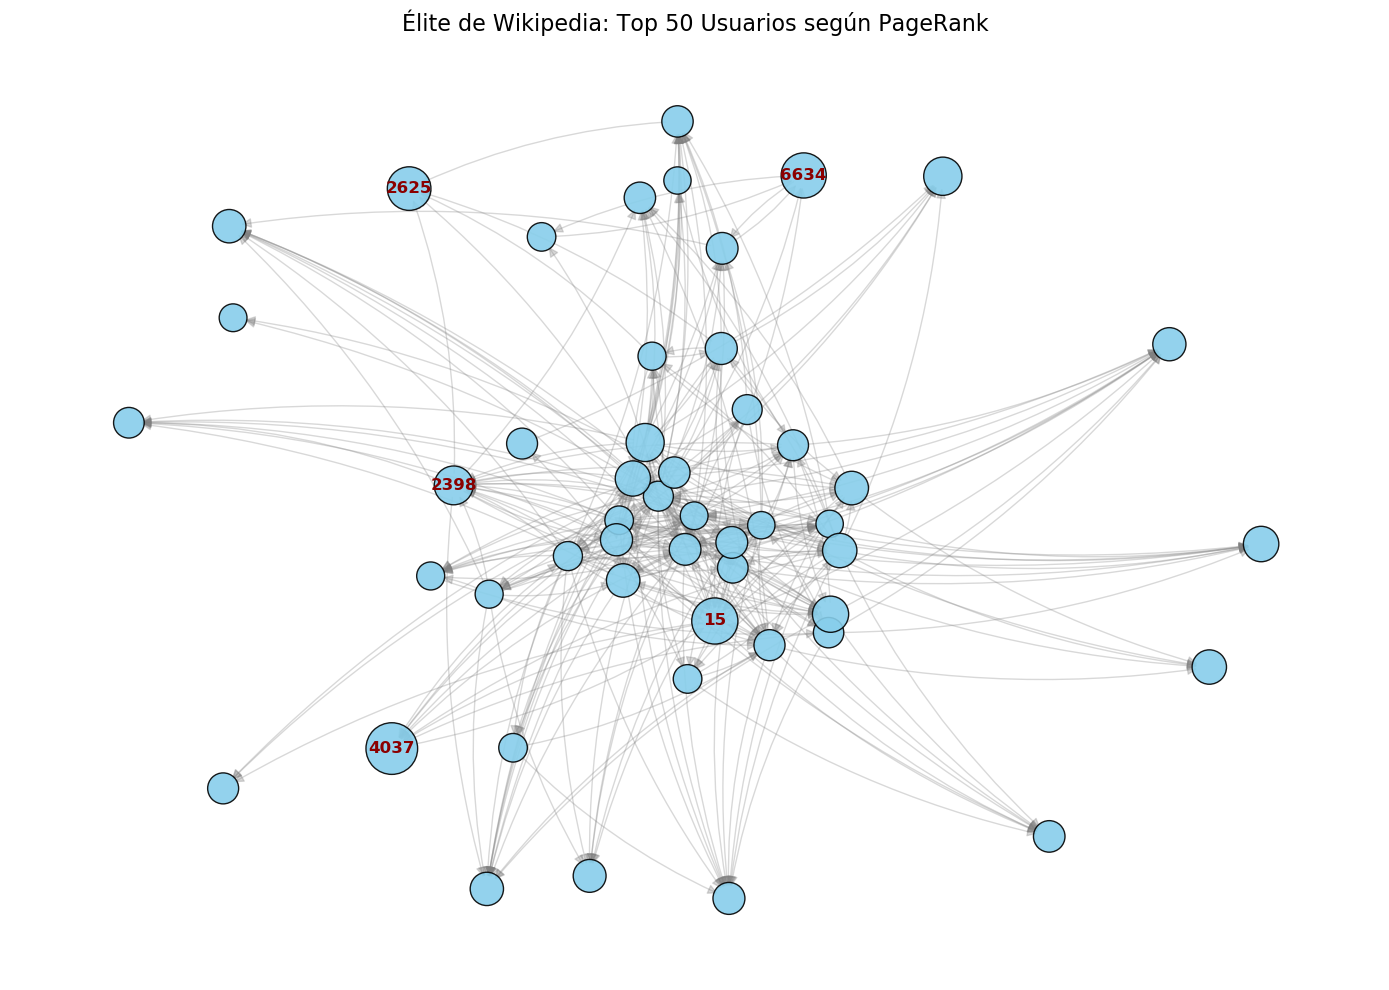

In [6]:
import matplotlib.pyplot as plt

print("Generando visualización del subgrafo de élite...")

# 1. Extraer los IDs de los 50 usuarios con mayor PageRank
# (Usamos el DataFrame 'resultados' completo que generamos en el paso 3)
top_50_ids = resultados.sort_values(by='Score PageRank', ascending=False).head(50)['ID Usuario'].tolist()

# 2. Crear un subgrafo que contenga solo a estos 50 nodos y las aristas entre ellos
subgrafo_elite = G.subgraph(top_50_ids)

# 3. Configurar el lienzo de Matplotlib
plt.figure(figsize=(14, 10))
plt.title("Élite de Wikipedia: Top 50 Usuarios según PageRank", fontsize=16)

# Calcular el layout (posicionamiento de los nodos). 
# spring_layout usa un modelo de fuerza dirigida que repele nodos no conectados y acerca los conectados.
posiciones = nx.spring_layout(subgrafo_elite, k=0.6, iterations=50, seed=42)

# Escalar el tamaño de los nodos proporcionalmente a su PageRank para la visualización
# Multiplicamos por un factor visual (ej. 300,000) porque los scores absolutos son números pequeños
tamanos_nodos = [pagerank_scores[nodo] * 300000 for nodo in subgrafo_elite.nodes()]

# 4. Dibujar los componentes de la red
# Nodos
nx.draw_networkx_nodes(subgrafo_elite, posiciones, 
                       node_size=tamanos_nodos, 
                       node_color='skyblue', 
                       alpha=0.9, 
                       edgecolors='black')

# Aristas (transparencia baja para no saturar la vista)
nx.draw_networkx_edges(subgrafo_elite, posiciones, 
                       alpha=0.3, 
                       arrows=True, 
                       arrowsize=15, 
                       edge_color='gray', 
                       connectionstyle='arc3,rad=0.1') # Curvar un poco las flechas

# 5. Etiquetas: Solo mostraremos los IDs de los 5 más altos para evitar texto superpuesto
top_5_ids = top_50_ids[:5]
etiquetas = {nodo: (nodo if nodo in top_5_ids else "") for nodo in subgrafo_elite.nodes()}
nx.draw_networkx_labels(subgrafo_elite, posiciones, 
                        labels=etiquetas, 
                        font_size=12, 
                        font_weight='bold', 
                        font_color='darkred')

plt.axis('off') # Ocultar los ejes de coordenadas
plt.tight_layout()
plt.show()